# LOCAL VERSION - Adapted to run outside Snowflake

**Key changes:**
- Removed Snowflake-specific session code
- Adapted Dask client initialization for local environment
- All other code remains identical

## 2026 EY AI & Data Challenge - TerraClimate Demonstration Notebook

This notebooks demonstrates how to access the TerraClimate dataset. TerraClimate is a dataset of monthly climate and climatic water balance for global terrestrial surfaces from 1958 to the present. These data provide important inputs for ecological and hydrological studies at global scales that require high spatial resolution and time-varying data. All data have monthly temporal resolution and a ~4-km (1/24th degree) spatial resolution. This dataset is provided in Zarr format. 

For more information, visit: https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

## Load In Dependencies

In [12]:
# Supress Warnings 
import warnings
warnings.filterwarnings('ignore')

# Import common GIS tools
import xarray as xr

# Import Planetary Computer tools
import pystac_client
import planetary_computer 
import dask 

# Dask is a dependency of xarray, so it will already be installed.
from dask.distributed import Client

# import Numpy
import numpy as np

print("✓ All packages imported successfully!")

✓ All packages imported successfully!


In [13]:
# Initialize Dask client for local execution
client = Client(memory_limit='2GB', processes=False)
print(f"✓ Dask client initialized: {client}")

✓ Dask client initialized: <Client: 'inproc://10.57.0.90/94672/10' processes=1 threads=4, memory=1.86 GiB>


## Loading TerraClimate Data

In [14]:
# Access STAC catalog and collection
print("Connecting to Planetary Computer...")
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace)

collection = catalog.get_collection("terraclimate")
asset = collection.assets["zarr-abfs"]
print("✓ Connected to TerraClimate collection")

Connecting to Planetary Computer...
✓ Connected to TerraClimate collection


In [15]:
# Open dataset and remove CRS
print("Loading TerraClimate dataset... (this may take a minute)")
ds = xr.open_dataset(asset.href, **asset.extra_fields["xarray:open_kwargs"])
ds = ds.drop('crs', dim=None) # Remove the CRS coordinate in the dataset
print("✓ Dataset loaded")

Loading TerraClimate dataset... (this may take a minute)


✓ Dataset loaded


A list of the available parameters is shown below:
- **aet**: Actual Evapotranspiration
- **def**: Climate Water Deficit
- **pet**: Potential Evapotranspiration
- **ppt**: Precipitation
- **q**: Runoff
- **soil**: Soil Moisture
- **srad**: Solar Radiation
- **swe**: Snow Water Equivalent
- **tmax**: Maximum Temperature
- **tmin**: Minimum Temperature
- **vap**: Vapor Pressure
- **ws**: Wind Speed

In [16]:
# Since this is a HUGE dataset (nearly 2 TB), we should parse the dataset
# Trimming dataset to years 2011 through 2015
print("Filtering dataset to 2011-2015...")
ds = ds.sel(time=slice("2011-01-01", "2015-12-31"))
print(f"✓ Filtered to {len(ds.time)} time steps")

Filtering dataset to 2011-2015...
✓ Filtered to 60 time steps


In [17]:
# Sample region in South Africa
# Contains Water Quality Sample Site #184 and #186 on Wilge River
lat_long = (-27.2923, 28.5365) # Lat-Lon centroid location
box_size_deg = 0.15 # Surrounding box in degrees

In [18]:
# Calculate the Lat-Lon bounding box region
min_lon = lat_long[1]-box_size_deg/2
min_lat = lat_long[0]-box_size_deg/2
max_lon = lat_long[1]+box_size_deg/2
max_lat = lat_long[0]+box_size_deg/2
print(f"Bounding box: lon({min_lon:.4f}, {max_lon:.4f}), lat({min_lat:.4f}, {max_lat:.4f})")

Bounding box: lon(28.4615, 28.6115), lat(-27.3673, -27.2173)


In [19]:
mask_lon = (ds.lon >= min_lon) & (ds.lon <= max_lon)
mask_lat = (ds.lat >= min_lat) & (ds.lat <= max_lat)

In [20]:
# Crop the dataset to smaller Lat-Lon regions
print("Cropping to region of interest...")
ds = ds.where(mask_lon & mask_lat, drop=True)
print("✓ Dataset cropped")
display(ds)

Cropping to region of interest...
✓ Dataset cropped


<xarray.Dataset> Size: 66kB
Dimensions:  (time: 60, lat: 4, lon: 4)
Coordinates:
  * lat      (lat) float64 32B -27.23 -27.27 -27.31 -27.35
  * lon      (lon) float64 32B 28.48 28.52 28.56 28.6
  * time     (time) datetime64[ns] 480B 2011-01-01 2011-02-01 ... 2015-12-01
Data variables: (12/14)
    aet      (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    def      (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    pdsi     (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    pet      (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    ppt      (time, lat, lon) float64 8kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    q        (time, lat, lon) float64 8kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    ...       ...
    swe      (time, lat, lon) float64 8kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    tmax     (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    tmin     (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    vap      (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    vpd      (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
    ws       (time, lat, lon) float32 4kB dask.array<chunksize=(12, 4, 4), meta=np.ndarray>
Attributes: (12/52)
    Conventions:                     CF-1.6
    acknowledgment:                  Please cite the references included here...
    cdm_data_type:                   GRID
    contributor_email:               khegewisch@ucmerced.edu
    contributor_name:                Katherine Hegewisch
    contributor_role:                Postdoctoral Fellow
    ...                              ...
    time_coverage_duration:          P1Y
    time_coverage_end:               1958-12-01T00:0
    time_coverage_resolution:        P1M
    time_coverage_start:             1958-01-01T00:0
    title:                           TerraClimate: monthly climate and climat...
    version:                         v1.0

## Exploring the Data

Plotting precipitation data...


✓ Plot complete


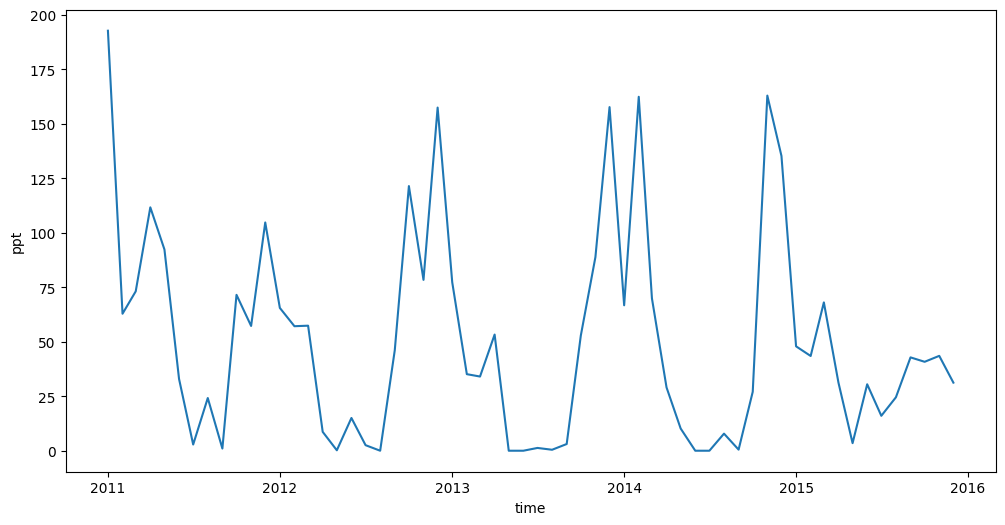

In [21]:
# Plot monthly accumulated precipitation over the region for 5 years
print("Plotting precipitation data...")
temperature = ds["ppt"].mean(dim=["lat", "lon"])
temperature.plot(figsize=(12, 6))
print("✓ Plot complete")

Plotting PET data...
✓ Plot complete


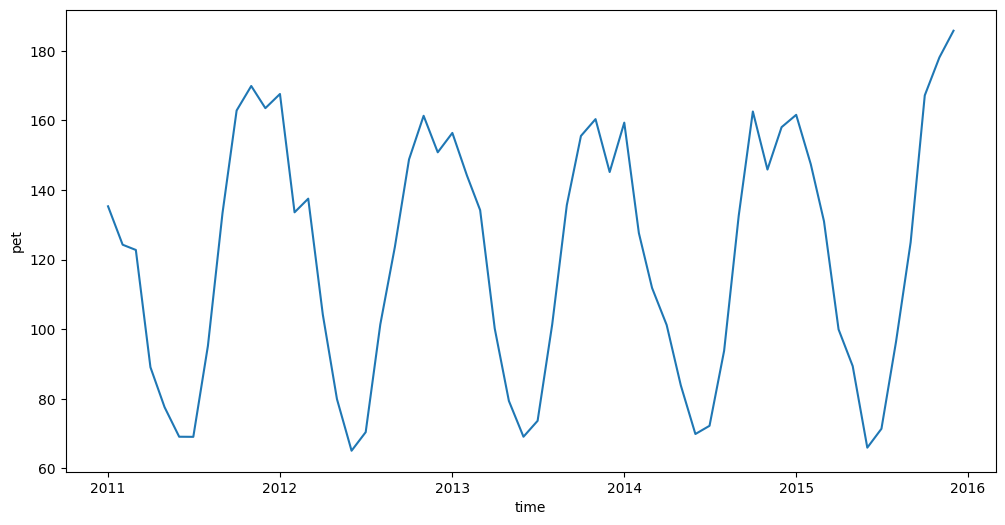

In [22]:
# Plot monthly reference evapotransporation over the region for 5 years
print("Plotting PET data...")
temperature = ds["pet"].mean(dim=["lat", "lon"])
temperature.plot(figsize=(12, 6))
print("✓ Plot complete")